## 项目步骤

1. 导入库
2. 导入数据
3. 数据概览
4. 数据清洗
5. 新数据特征构造
6. 问题分析及可视化

In [1]:
# 1. 导入最近学习的库
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
from scipy import stats
from matplotlib import rcParams

# 设置中文字体，避免以后画图时中文显示成方框
rcParams['font.sans-serif'] = ['SimHei']
rcParams['axes.unicode_minus'] = False

df =pd.read_csv('house.csv')#导入数据
#概览一下
print(len(df.columns))
df.drop(columns ='url', inplace=True )

df.isna().sum()
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)
print(len(df))
df['area']=df['area'].str.replace('m²','').astype(float)
#print(df.head())
#print(df.info())
df['toward'].astype('category')

df['year'] = df['year'].str.replace('年建','').astype('int')#把一些中文标注删去

print(df.head())




12
58
  city         address   area     floor   name price province rooms toward  \
0   合肥  临泉东路与王岗大道交口东南角   90.0  中层(共18层)   圣地亚哥  128万       安徽  3室2厅    南北向   
2   合肥      淮海大道与大众路交口   95.0  中层(共18层)  正荣悦都荟  132万       安徽  3室2厅     南向   
3   合肥      繁华大道与翡翠路交口   88.0  高层(共33层)   禹洲天境  165万       安徽  3室2厅    南北向   
4   合肥       潜山路与祁门路交口   76.0  低层(共24层)  华润幸福里  146万       安徽  2室2厅     南向   
5   合肥      长江东路与和县路交口  108.0  中层(共26层)   保利东郡  178万       安徽  3室2厅    南北向   

        unit  year  
0  14222元/m²  2013  
2  13895元/m²  2019  
3  18750元/m²  2016  
4  19211元/m²  2012  
5  16481元/m²  2017  


In [2]:
#构造新数据类型
df['floor_type'] = df['floor'].str.split('(').str[0]
print(df.head())



  city         address   area     floor   name price province rooms toward  \
0   合肥  临泉东路与王岗大道交口东南角   90.0  中层(共18层)   圣地亚哥  128万       安徽  3室2厅    南北向   
2   合肥      淮海大道与大众路交口   95.0  中层(共18层)  正荣悦都荟  132万       安徽  3室2厅     南向   
3   合肥      繁华大道与翡翠路交口   88.0  高层(共33层)   禹洲天境  165万       安徽  3室2厅    南北向   
4   合肥       潜山路与祁门路交口   76.0  低层(共24层)  华润幸福里  146万       安徽  2室2厅     南向   
5   合肥      长江东路与和县路交口  108.0  中层(共26层)   保利东郡  178万       安徽  3室2厅    南北向   

        unit  year floor_type  
0  14222元/m²  2013         中层  
2  13895元/m²  2019         中层  
3  18750元/m²  2016         高层  
4  19211元/m²  2012         低层  
5  16481元/m²  2017         中层  


In [3]:
# 价格分段 price_labels
# 先把128万变成128.0；astype(str)
df['price'] = pd.to_numeric(
    df['price'].astype(str).str.replace('万', '', regex=False)
)

df['price_labels'] = pd.cut(
    df['price'],
    bins=4,
    labels=['低价', '中价', '高价', '豪华'],
    include_lowest=True
)

print(df[['price', 'price_labels']].head())
print(df['price_labels'].value_counts().sort_index())

   price price_labels
0    128           低价
2    132           低价
3    165           低价
4    146           低价
5    178           低价
price_labels
低价    42
中价    13
高价     2
豪华     1
Name: count, dtype: int64


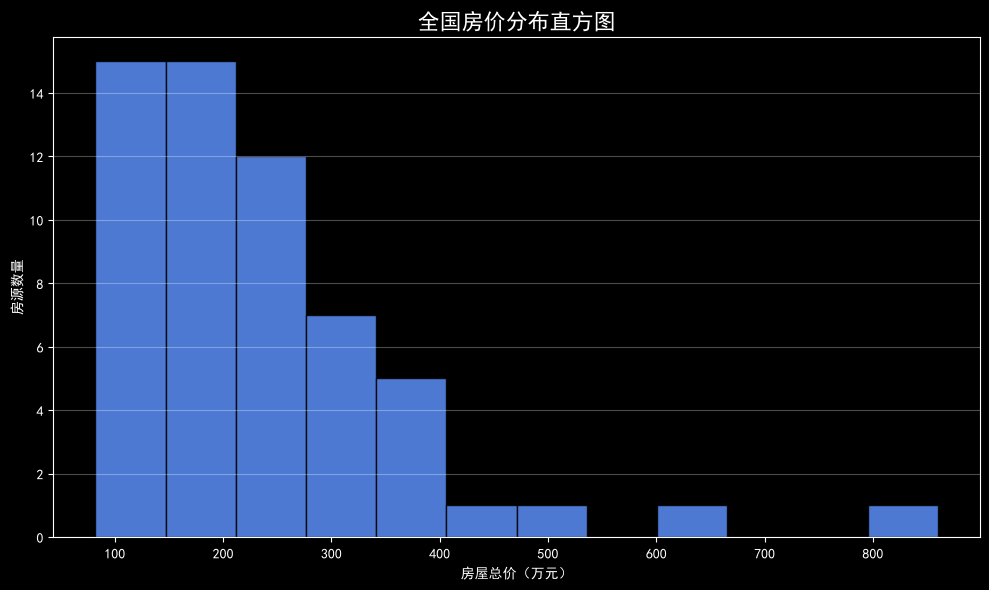

In [26]:
# 全国房价分布直方图
plt.figure(figsize=(10, 6))
plt.hist(df['price'], bins=12, color='#5B8FF9', edgecolor='black', alpha=0.85)
plt.title('全国房价分布直方图', fontsize=16)
plt.xlabel('房屋总价（万元）')
plt.ylabel('房源数量')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

# 要先保存再显示，否则有些环境导出的图片会是空白
plt.savefig('pic.png', dpi=600, bbox_inches='tight')
plt.show()